# **IDENTIFICACIÓN DE ESPECIES DE AVES, ANFIBIOS, MAMÍFEROS E INSECTOS A PARTIR DE GRABACIONES DE AUDIO EN EL VALLE DEL MAGDALENA MEDIO**
### Duvan Fernando Lombana Bejarano
### UNAL

### **Introducción**
Cuando se realizan esfuerzos de restauración ecológica con el objetivo de devolverle a los hábitats su biodiversidad y funcionalidad natural, se usan métodos para evaluar los resultados de estas medidas como determinar las variaciones y dinámicas poblacionales de las especies que allí conviven.

Medir el comportamiento de la flora es un proceso estático y predecible, pero rastrear la fauna exige un esfuerzo mayor como los censos de biodiversidad tradicionales en los que un grupo de investigadores deben realizar caminatas a lo largo del día intentando estimar la abundancia de animales a través de la agudeza de sus sentidos, esto en algunos casos conlleva datos perdidos o mal registrados debido al sesgo y error humano, sin contar que las especies más tímidas o en peligro de extinción pueden huir de la presencia humana, llevando a pensar que la especie ya no habita el entorno.

Con el fin de mejorar este seguimiento, que en algunos casos es costoso y logísticamente complejo, se introdujo el Monitoreo Acústico Pasivo (MAP), que consiste en instalar grabadoras digitales en el ecosistema para registrar continuamente o en intervalos de tiempo, los sonidos del ambiente sin alterar el comportamiento de la fauna; sin embargo esto produce un "tsunami de datos acústicos", con lo que el reto ahora es poder procesar estas miles de horas de audio.

Pensando en este problema se lanzó *BirdCLEF+ 2025*, una competencia global de Inteligencia Artificial organizada en la plataforma *Kaggle* por instituciones como el Instituto Humboldt de Colombia, Google Research, iNaturalist y la Universidad Tecnológica de Chemnitz, cuyo objetivo principal es invitar a expertos en datos a desarrollar algoritmos capaces de identificar múltiples grupos taxonómicos de forma automática a partir de archivos de audio capturados en la *Reserva Natural El Silencio*, ubicada en el Valle del Magdalena Medio, que fue destruida en el pasado por la ganadería extensiva y ahora atraviesa un proceso de restauración ecológica.

En este proyecto se replica uno de los modelos presentados para esta competencia, con un enfoque en evaluar empíricamente el comportamiento del modelo frente a diferentes configuraciones de optimizadores y planificadores de tasa de aprendizaje *learning rate schedulers*, optimizando la métrica oficial de validación.




### **Trabajo original**
El presente estudio toma como referencia directa y réplica metodológica la solución de línea base desarrollada en $2025$ por *Kadircan İdrisoğlu*, Científico de datos e Ingeniero de Machine Learning originario de Estambul, Turquía de la Universidad Eskişehir Osmangazi. İdrisoğlu trabaja como Científico de datos en World from Space, una compañía europea enfocada en el análisis de datos geoespaciales y de observación de la Tierra mediante satélites. Dicha propuesta destaca por el uso eficiente de una arquitectura convolucional optimizada, el empleo de técnicas de aumento de datos espaciales como *Mixup* o *SpecAugment*, y un esquema sólido de validación cruzada diseñado para mitigar el desbalance masivo de clases inherente a las grabaciones de campo.

El trabajo original se encuentra en el siguiente enlace:
https://www.kaggle.com/code/kadircandrisolu/efficientnet-b0-pytorch-train-birdclef-25

La contribución principal de este informe radica en una extensión experimental y un análisis comparativo de la fase de entrenamiento. Específicamente, se evalúa el comportamiento del modelo frente a combinaciones de optimizadores adaptativos y tradicionales como *AdamW* y *SGD* y planificadores de tasa de aprendizaje como *CosineAnnealingLR* y *ReduceLROnPlateau*, monitorizando su impacto en la métrica oficial *Macro ROC-AUC*.

### **Conjunto de datos**
El conjunto de datos empleado consiste en $28\ 564$ grabaciones cortas de sonidos individuales de aves, anfibios, mamíferos e insectos de $32$ kHz en formato *.ogg* extraídos de la base oficial de *BirdCLEF*, que a su vez han sido subidos por usuarios de xeno-canto.org , iNaturalist y el Archivo Sonoro Colombiano (CSA) del Instituto Humboldt de Investigación de Recursos Biológicos en Colombia. Las grabaciones han sido realizadas en la Reserva Natural El Silencio, Colombia y buscan identificar cerca de $206$ especies.

También se tiene un archivo de metadatos etiquetados asociados a los audios que proporcionan información sobre la especie principal que se presenta en la grabación, otras especies que se escuchan de fondo, las coordenadas del lugar de grabación, el nivel de calidad del audio, el nombre del autor del audio y su colección de origen.

### **Métodos**
**Arquitectura del Modelo**

Se tomó como base el modelo *EfficientNet-B0* que clasifica imágenes en $1\ 000$ categorías y es preentrenado con ImageNet, siendo hasta $8.4$ veces más pequeño y $16$ veces más rápido que modelos como ResNet, cuenta con una resolución de entrada de $224\times 224$ píxeles y $5.3$ millones de parámetros.




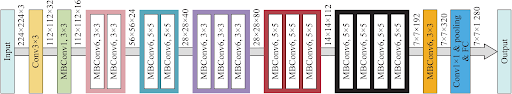

Con el objetivo de aplicar el aprendizaje por transferencia, se realizó una adaptación para que recibiera como entrada los espectrogramas en blanco y negro, ya que el modelo está diseñado para recibir imágenes a color de $3$ canales RGB, luego se elimina la capa de clasificación original y se reemplaza por una capa que solo deja pasar los datos, posteriormente se agrega una capa de Agrupamiento Promedio Global que aplana los datos, es decir, cambia el tamaño de cada tensor a *(tamaño del lote, 1, 1, 1)* al realizar el promedio de los valores de  la matriz que representa cada espectrograma. Después se añade una nueva capa lineal adaptada al número de especies que se deben clasificar.

**Métrica de Evaluación**

La evaluación se rige bajo la métrica *Macro ROC-AUC*, que calcula el área bajo la curva de características operativas del receptor de forma independiente para cada una de
las especies y promedia aritméticamente sus resultados, asegurando una protección de rendimiento equitativa tanto para especies comunes como para especies raras en peligro de extinción, esto es útil dado que *BirdCLEF* tiene un problema severo de clases desbalanceadas (hay especies de aves con miles de grabaciones y otras con apenas dos o tres), esto obliga al modelo a ser igual de bueno identificando especies comunes y raras, ya que todas pesan lo mismo en el puntaje final.

**Función de pérdida**

Debido a la naturaleza multietiqueta del espacio de salida, la función de costo seleccionada fue la Entropía Cruzada Binaria con Logits Integrados *BCEWithLogitsLoss*, definida para $N$ clases como:

\begin{equation*}
\mathcal{L}_{BCE} = -\frac{1}{N} \sum_{i=1}^{N} \big( y_i \cdot \ln( \sigma(x_i)) + (1 - y_i) \cdot \ln(1 - \sigma(x_i)) \big)
\end{equation*}
donde $\sigma(x)$ representa la función sigmoide.

### **Modelo**
**1)** Se importan las librerías necesarias para ejecutar el código, a continuación se listan algunas con sus funciones:

**gc:** Sirve para liberar memoria RAM borrando variables pesadas no necesarias, esto es útil debido al consumo de memoria generado por los archivos de audio y los espectogramas.

**cv2:** Sirve para redimensionalizar y manipular los espectrogramas.

**librosa:** Sirve para cargar los audios y extraer las características que permiten producir los espectrogramas.

**StratifiedKFold:** Sirve para llevar a cabo la validación cruzada, es decir, divide los datos en K partes que mantienen la misma proporción de especies que el dataset completo.

**roc_auc_score:** Sirve para introducir la métrica Áreas bajo la curva ROC.

**nn, F:** Sirven para introducir los bloques de construcción para las capas de las redes neuronales como convoluciones, funciones dce activación, etc.

**optim:** Sirve para introducir el optimizador.

**lr_schedule:** Sirve para reducir la tasa de aprendizaje conforme el modelo avanza.

**Dataset:** Sirve para definir cómo cargar una sola muestra.

**DataLoader:** Sirve para agrupar las muestras en lotes y así enviarlos eficientemente a la GPU.

**timm:** Contiene cientos de modelos de visión por computadora preentrenados listos para usar.


In [ ]:
import os
import logging
import random
import gc
import time
import cv2
import math
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, auc, roc_curve
import librosa

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import timm

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.ERROR)


**2)** Se descargan los datos oficiales de la competencia BirdCLEF+ 2025 y se descomprime la carpeta descargada.

In [ ]:
# 1. Configura tu token de API (Copia el de la ventana anterior)
os.environ["KAGGLE_API_TOKEN"] = "KGAT_b778a9f9265350740e15609386a04df4"

print("✅ Autenticación configurada.")

# --- DESCARGA 1: COMPETICIÓN (BirdCLEF 2025) ---
print("\n📥 Descargando datos de la competición BirdCLEF 2025...")
# Creamos una carpeta específica para no mezclar los archivos
os.makedirs("birdclef_competition", exist_ok=True)
os.system(
    "kaggle competitions download -c birdclef-2025 -p birdclef_competition"
)
os.system("unzip -o birdclef_competition/*.zip -d birdclef_competition/ && rm birdclef_competition/*.zip")

# --- DESCARGA 2: CONJUNTO DE DATOS (Espectrogramas Mel) ---
print("\n📥 Descargando dataset de Espectrogramas Mel...")
# Creamos otra carpeta independiente
os.makedirs("birdclef_spectrograms", exist_ok=True)

# NOTA: Kaggle traduce los nombres en interfaz, el comando real usa la estructura en inglés o ID técnico.
# Si al ejecutar el comando de abajo te da error, haz clic en los 3 puntos que aparecen al lado de
# "BirdCLEF'25 | Espectrogramas Mel" en tu pantalla de Kaggle, elige "Copy API command" y reemplaza el texto de abajo.
DATASET_ID = "ipythonx/birdclef25-mel-spectrograms-5sec-256x256"

os.system(f"kaggle datasets download -d {DATASET_ID} -p birdclef_spectrograms")
os.system("unzip -o birdclef_spectrograms/*.zip -d birdclef_spectrograms/ && rm birdclef_spectrograms/*.zip")

print("\n🎉 ¡Proceso finalizado! Revisa las carpetas creadas en tu menú izquierdo de Colab.")


✅ Autenticación configurada.

📥 Descargando datos de la competición BirdCLEF 2025...

📥 Descargando dataset de Espectrogramas Mel...

🎉 ¡Proceso finalizado! Revisa las carpetas creadas en tu menú izquierdo de Colab.


A continuación se muestra el tamaño del dataset de audios

In [ ]:
# 1. Definimos las rutas exactas de los archivos según las carpetas del paso anterior
ruta_csv = "birdclef_competition/train.csv"

# 2. Cargamos el archivo CSV usando la ruta directa
train_df = pd.read_csv(ruta_csv)

# .shape nos dice (filas, columnas)
print(
    f"El dataset contiene {train_df.shape[0]} grabaciones de audio y {train_df.shape[1]} columnas de información."
)



El dataset contiene 28564 grabaciones de audio y 13 columnas de información.


**3)** Se centraliza la configuración, lo que permite ajustar algunos parámetros como el tamaño del lote, el número de épocas, además de definir el algoritmo que ajusta los pesos de la red

In [ ]:
class CFG:

    seed = 42
    debug = False
    apex = False
    print_freq = 100
    num_workers = 2

    OUTPUT_DIR = '/content/'                                                     # Carpeta donde se guardarán los resultados y el modelo entrenado

    train_datadir = "birdclef_competition/train_audio"                       # Rutas de los datos oficiales de la competencia
    train_csv = "birdclef_competition/train.csv"
    test_soundscapes = "birdclef_competition/train_soundscapes"
    submission_csv = "birdclef_competition/sample_submission.csv"
    taxonomy_csv = "birdclef_competition/taxonomy.csv"


    model_name = 'efficientnet_b0'                                               # Modelo elegido
    pretrained = True
    in_channels = 1                                                              # Un solo canal (escala de grises)

    LOAD_DATA = True
    FS = 32000                                                                   # Frecuencia de muestreo 32 kHz
    TARGET_DURATION = 5.0                                                        # Corta las grabaciones en fragmentos de 5 seg
    TARGET_SHAPE = (256, 256)

    N_FFT = 1024
    HOP_LENGTH = 512
    N_MELS = 128
    FMIN = 50
    FMAX = 14000

    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    epochs = 10
    batch_size = 32
    criterion = 'BCEWithLogitsLoss'                                              # Función de pérdida Entropía Cruzada Binaria

    n_fold = 5                                                                   # Validación cruzada de 5 pliegues
    selected_folds = [0, 1, 2, 3, 4]

    optimizer = 'AdamW'                                                          # Optimizador AdamW (ajusta los pesos de la red)
    lr = 5e-4
    weight_decay = 1e-5

    scheduler = 'ReduceLROnPlateau'                                             # Reduce la tasa de aprendizaje siguiendo una curva de coseno
    min_lr = 1e-6
    T_max = epochs

    aug_prob = 0.5
    mixup_alpha = 0.5

    def update_debug_settings(self):
        if self.debug:
            self.epochs = 2
            self.selected_folds = [0]

cfg = CFG()


**4)** Se fija una semilla que permita hacer el modelo determinista, es decir, que no dependa del azar y que al partir de los mismos datos se llegue al mismo resultado.

In [ ]:
def set_seed(seed=42):
    """
    Set seed for reproducibility
    """
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(cfg.seed)

**5)** Se toma una matriz de audio y se verifica si hay valores nulos (si los hay los reemplaza por la media de la señal), luego extrae las características para convertir la potencia en decibelios y normaliza los píxeles.

Se estandariza el tamaño a $5$ segundos. Para audios con una duración mayor se toma el centro exacto de la grabación y para los de menor duración se concatena hasta llegar a la duración requerida, luego se convierte el audio a espectrograma y se ajusta a imagen a $256 \times 256$ píxeles.

Se toma un dataframe de pandas y usa un bucle for para procesar audios uno por uno, hasta llegar a mil, cada matriz resultante se guarda en un diccionario, usando el nombre de archivo como llave.

In [ ]:
def audio2melspec(audio_data, cfg):
    """Convert audio data to mel spectrogram"""
    if np.isnan(audio_data).any():
        mean_signal = np.nanmean(audio_data)
        audio_data = np.nan_to_num(audio_data, nan=mean_signal)

    mel_spec = librosa.feature.melspectrogram(
        y=audio_data,
        sr=cfg.FS,
        n_fft=cfg.N_FFT,
        hop_length=cfg.HOP_LENGTH,
        n_mels=cfg.N_MELS,
        fmin=cfg.FMIN,
        fmax=cfg.FMAX,
        power=2.0
    )

    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
    mel_spec_norm = (mel_spec_db - mel_spec_db.min()) / (mel_spec_db.max() - mel_spec_db.min() + 1e-8)

    return mel_spec_norm

def process_audio_file(audio_path, cfg):
    """Process a single audio file to get the mel spectrogram"""
    try:
        audio_data, _ = librosa.load(audio_path, sr=cfg.FS)

        target_samples = int(cfg.TARGET_DURATION * cfg.FS)

        if len(audio_data) < target_samples:
            n_copy = math.ceil(target_samples / len(audio_data))
            if n_copy > 1:
                audio_data = np.concatenate([audio_data] * n_copy)

        # Extract center 5 seconds
        start_idx = max(0, int(len(audio_data) / 2 - target_samples / 2))
        end_idx = min(len(audio_data), start_idx + target_samples)
        center_audio = audio_data[start_idx:end_idx]

        if len(center_audio) < target_samples:
            center_audio = np.pad(center_audio,
                                 (0, target_samples - len(center_audio)),
                                 mode='constant')

        mel_spec = audio2melspec(center_audio, cfg)

        if mel_spec.shape != cfg.TARGET_SHAPE:
            mel_spec = cv2.resize(mel_spec, cfg.TARGET_SHAPE, interpolation=cv2.INTER_LINEAR)

        return mel_spec.astype(np.float32)

    except Exception as e:
        print(f"Error processing {audio_path}: {e}")
        return None

def generate_spectrograms(df, cfg):
    """Generate spectrograms from audio files"""
    print("Generating mel spectrograms from audio files...")
    start_time = time.time()

    all_bird_data = {}
    errors = []

    for i, row in tqdm(df.iterrows(), total=len(df)):
        if cfg.debug and i >= 1000:
            break

        try:
            samplename = row['samplename']
            filepath = row['filepath']

            mel_spec = process_audio_file(filepath, cfg)

            if mel_spec is not None:
                all_bird_data[samplename] = mel_spec

        except Exception as e:
            print(f"Error processing {row.filepath}: {e}")
            errors.append((row.filepath, str(e)))

    end_time = time.time()
    print(f"Processing completed in {end_time - start_time:.2f} seconds")
    print(f"Successfully processed {len(all_bird_data)} files out of {len(df)}")
    print(f"Failed to process {len(errors)} files")

    return all_bird_data

**6)** Se lee el archivo *taxonomy.csv* para saber cuántas especies hay involucradas en el dataset, luego se le asigna un número a cada ave. Posteriormente, se verifica si hay espectrogramas pre-calculados para cada audio del dataset, en caso de que no hayan, se genera uno usando la función *process_audio_file*, finalmente se aplica la técnica one-hot encoding para señalar las especies que intervienen en cada audio.

En el modo de entrenamiento, en cada época para cada espectrograma hay una probabilidad de $0.5$ de que a este se le aplique un aumento de datos aplicando tres técnicas: En mascaramiento temporal, Enmascaramiento de frecuencia y Brillo y contraste aleatorio.

In [ ]:
class BirdCLEFDatasetFromNPY(Dataset):
    def __init__(self, df, cfg, spectrograms=None, mode="train"):
        self.df = df
        self.cfg = cfg
        self.mode = mode

        self.spectrograms = spectrograms

        taxonomy_df = pd.read_csv(self.cfg.taxonomy_csv)
        self.species_ids = taxonomy_df['primary_label'].tolist()
        self.num_classes = len(self.species_ids)
        self.label_to_idx = {label: idx for idx, label in enumerate(self.species_ids)}

        if 'filepath' not in self.df.columns:
            self.df['filepath'] = self.cfg.train_datadir + '/' + self.df.filename

        if 'samplename' not in self.df.columns:
            self.df['samplename'] = self.df.filename.map(lambda x: x.split('/')[0] + '-' + x.split('/')[-1].split('.')[0])

        sample_names = set(self.df['samplename'])
        if self.spectrograms:
            found_samples = sum(1 for name in sample_names if name in self.spectrograms)
            print(f"Found {found_samples} matching spectrograms for {mode} dataset out of {len(self.df)} samples")

        if cfg.debug:
            self.df = self.df.sample(min(1000, len(self.df)), random_state=cfg.seed).reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        samplename = row['samplename']
        spec = None

        if self.spectrograms and samplename in self.spectrograms:
            spec = self.spectrograms[samplename]
        elif not self.cfg.LOAD_DATA:
            spec = process_audio_file(row['filepath'], self.cfg)

        if spec is None:
            spec = np.zeros(self.cfg.TARGET_SHAPE, dtype=np.float32)
            if self.mode == "train":  # Only print warning during training
                print(f"Warning: Spectrogram for {samplename} not found and could not be generated")

        spec = torch.tensor(spec, dtype=torch.float32).unsqueeze(0)  # Add channel dimension

        if self.mode == "train" and random.random() < self.cfg.aug_prob:
            spec = self.apply_spec_augmentations(spec)

        target = self.encode_label(row['primary_label'])

        if 'secondary_labels' in row and row['secondary_labels'] not in [[''], None, np.nan]:
            if isinstance(row['secondary_labels'], str):
                secondary_labels = eval(row['secondary_labels'])
            else:
                secondary_labels = row['secondary_labels']

            for label in secondary_labels:
                if label in self.label_to_idx:
                    target[self.label_to_idx[label]] = 1.0

        return {
            'melspec': spec,
            'target': torch.tensor(target, dtype=torch.float32),
            'filename': row['filename']
        }

    def apply_spec_augmentations(self, spec):
        """Apply augmentations to spectrogram"""

        # Time masking (horizontal stripes)
        if random.random() < 0.5:
            num_masks = random.randint(1, 3)
            for _ in range(num_masks):
                width = random.randint(5, 20)
                start = random.randint(0, spec.shape[2] - width)
                spec[0, :, start:start+width] = 0

        # Frequency masking (vertical stripes)
        if random.random() < 0.5:
            num_masks = random.randint(1, 3)
            for _ in range(num_masks):
                height = random.randint(5, 20)
                start = random.randint(0, spec.shape[1] - height)
                spec[0, start:start+height, :] = 0

        # Random brightness/contrast
        if random.random() < 0.5:
            gain = random.uniform(0.8, 1.2)
            bias = random.uniform(-0.1, 0.1)
            spec = spec * gain + bias
            spec = torch.clamp(spec, 0, 1)

        return spec

    def encode_label(self, label):
        """Encode label to one-hot vector"""
        target = np.zeros(self.num_classes)
        if label in self.label_to_idx:
            target[self.label_to_idx[label]] = 1.0
        return target

**7)** Se revisa la lista de elementos del dataset, en caso de que algún elemento falle, lo descarta para evitar el colapso del entrenamiento, luego al apilar los elementos que pasan el filtro anterior, crea tensores con la forma *(tamaño del lote, número de canales, alto, ancho)*, donde ya sabemos que el número de canales es 1 y tamaño de cada espectrograma es de 256 de alto por 256 de ancho, de este modo, el dataset se divide en bloques de este tipo.

In [ ]:
def collate_fn(batch):
    """Custom collate function to handle different sized spectrograms"""
    batch = [item for item in batch if item is not None]
    if len(batch) == 0:
        return {}

    result = {key: [] for key in batch[0].keys()}

    for item in batch:
        for key, value in item.items():
            result[key].append(value)

    for key in result:
        if key == 'target' and isinstance(result[key][0], torch.Tensor):
            result[key] = torch.stack(result[key])
        elif key == 'melspec' and isinstance(result[key][0], torch.Tensor):
            shapes = [t.shape for t in result[key]]
            if len(set(str(s) for s in shapes)) == 1:
                result[key] = torch.stack(result[key])

    return result


**8)** Para aplicar el Aprendizaje por Transferencia, se carga el modelo en EfficientNet-b0 y se adapta para el conjunto de datos.

También se aplica una nueva técnica de aumento de datos llamada *Mixup*.

In [ ]:
class BirdCLEFModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg

        taxonomy_df = pd.read_csv(cfg.taxonomy_csv)
        cfg.num_classes = len(taxonomy_df)

        self.backbone = timm.create_model(
            cfg.model_name,
            pretrained=cfg.pretrained,
            in_chans=cfg.in_channels,
            drop_rate=0.2,
            drop_path_rate=0.2
        )

        if 'efficientnet' in cfg.model_name:
            backbone_out = self.backbone.classifier.in_features
            self.backbone.classifier = nn.Identity()
        elif 'resnet' in cfg.model_name:
            backbone_out = self.backbone.fc.in_features
            self.backbone.fc = nn.Identity()
        else:
            backbone_out = self.backbone.get_classifier().in_features
            self.backbone.reset_classifier(0, '')

        self.pooling = nn.AdaptiveAvgPool2d(1)

        self.feat_dim = backbone_out

        self.classifier = nn.Linear(backbone_out, cfg.num_classes)

        self.mixup_enabled = hasattr(cfg, 'mixup_alpha') and cfg.mixup_alpha > 0
        if self.mixup_enabled:
            self.mixup_alpha = cfg.mixup_alpha

    def forward(self, x, targets=None):

        if self.training and self.mixup_enabled and targets is not None:
            mixed_x, targets_a, targets_b, lam = self.mixup_data(x, targets)
            x = mixed_x
        else:
            targets_a, targets_b, lam = None, None, None

        features = self.backbone(x)

        if isinstance(features, dict):
            features = features['features']

        if len(features.shape) == 4:
            features = self.pooling(features)
            features = features.view(features.size(0), -1)

        logits = self.classifier(features)

        if self.training and self.mixup_enabled and targets is not None:
            loss = self.mixup_criterion(F.binary_cross_entropy_with_logits,
                                       logits, targets_a, targets_b, lam)
            return logits, loss

        return logits

    def mixup_data(self, x, targets):
        """Applies mixup to the data batch"""
        batch_size = x.size(0)

        lam = np.random.beta(self.mixup_alpha, self.mixup_alpha)

        indices = torch.randperm(batch_size).to(x.device)

        mixed_x = lam * x + (1 - lam) * x[indices]

        return mixed_x, targets, targets[indices], lam

    def mixup_criterion(self, criterion, pred, y_a, y_b, lam):
        """Applies mixup to the loss function"""
        return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

A continuación se muestra un dato de ejemplo y el espectrograma generado.

In [ ]:
def visualizar_muestra(ruta_audio):
    # 1. Cargar el archivo de audio (.ogg)
    # librosa convierte automáticamente el formato .ogg a un vector numérico
    y, sr = librosa.load(ruta_audio, sr=32000)

    print(f"🔊 Frecuencia de muestreo: {sr} Hz")
    print(f"⏱️ Duración del clip: {len(y) / sr:.2f} segundos")

    # 2. Crear la gráfica de la Onda de Sonido (Waveform)
    plt.figure(figsize=(12, 4))
    librosa.display.waveshow(y, sr=sr, color="teal", alpha=0.8)
    plt.title(
        f"Onda de Sonido: {os.path.basename(ruta_audio)}",
        fontsize=12,
        fontweight="bold",
    )
    plt.xlabel("Tiempo (Segundos)")
    plt.ylabel("Amplitud")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

    # 3. Insertar el reproductor de audio interactivo
    display(ipd.Audio(y, rate=sr))


🎵 AVE DETECTADA (Etiqueta Principal): YEOFLY1
📂 Nombre del archivo original: yeofly1/XC250351.ogg
📍 Ruta local en Colab: birdclef_competition/train_audio/yeofly1/XC250351.ogg
🔊 Frecuencia de muestreo: 32000 Hz
⏱️ Duración del clip: 5.43 segundos


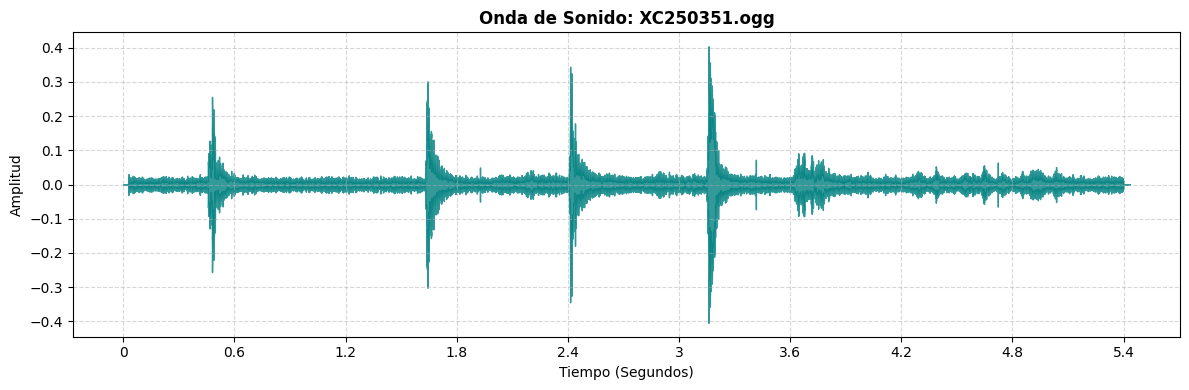

In [ ]:
# 1. Forzar las rutas exactas que encontramos en tu Colab
cfg.train_csv = "birdclef_competition/train.csv"
cfg.train_datadir = "birdclef_competition/train_audio"

# 2. Cargar el CSV de metadatos
train_df = pd.read_csv(cfg.train_csv)

# 3. Elegir una muestra aleatoria del DataFrame (Corregido con [0])
muestra = train_df.sample(15).iloc[0]

# 4. Construir la ruta exacta del archivo de audio (.ogg)
nombre_archivo = os.path.basename(muestra["filename"])
ruta_audio_real = os.path.join(
    cfg.train_datadir, muestra["primary_label"], nombre_archivo
)

print("==================================================================")
print(
    f"🎵 AVE DETECTADA (Etiqueta Principal): {muestra['primary_label'].upper()}"
)
print(f"📂 Nombre del archivo original: {muestra['filename']}")
print(f"📍 Ruta local en Colab: {ruta_audio_real}")
print("==================================================================")

# 5. Intentar graficar y reproducir el audio
try:
    visualizar_muestra(ruta_audio_real)
except NameError:
    print(
        "❌ Error: Asegúrate de haber ejecutado la función 'visualizar_muestra' al principio de tu cuaderno."
    )
except Exception as e:
    print(f"❌ No se pudo cargar el audio. Error: {e}")


**9)** Se controla cómo aprenderá el modelo a través de 3 funciones:

**Optimizador**

Ajusta los pesos de la red a partir de su predicción. El código permite evaluar las opciones Adam, AdamW y Descenso de Gradiente Estocástico (SGD): Este algoritmo aplica la misma Tasa de Aprendizaje Estricta a todos los pesos por igual.

**Planificador**

Se utiliza para reducir el tamaño de la tasa de aprendizaje con el pasar de las épocas. El modelo permite evaluar ReduceLROnPlateau, StepLR y CosineAnnealingLR.

**Función de Costo**

Mide qué tan acertada estuvo la predicción del modelo.


In [ ]:
def get_optimizer(model, cfg):

    if cfg.optimizer == 'Adam':
        optimizer = optim.Adam(
            model.parameters(),
            lr=cfg.lr,
            weight_decay=cfg.weight_decay
        )
    elif cfg.optimizer == 'AdamW':
        optimizer = optim.AdamW(
            model.parameters(),
            lr=cfg.lr,
            weight_decay=cfg.weight_decay
        )
    elif cfg.optimizer == 'SGD':
        optimizer = optim.SGD(
            model.parameters(),
            lr=cfg.lr,
            momentum=0.9,
            weight_decay=cfg.weight_decay
        )
    else:
        raise NotImplementedError(f"Optimizer {cfg.optimizer} not implemented")

    return optimizer

def get_scheduler(optimizer, cfg):

    if cfg.scheduler == 'CosineAnnealingLR':
        scheduler = lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=cfg.T_max,
            eta_min=cfg.min_lr
        )
    elif cfg.scheduler == 'ReduceLROnPlateau':
        scheduler = lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode='min',
            factor=0.5,
            patience=2,
            min_lr=cfg.min_lr
        )
    elif cfg.scheduler == 'StepLR':
        scheduler = lr_scheduler.StepLR(
            optimizer,
            step_size=cfg.epochs // 3,
            gamma=0.5
        )
    elif cfg.scheduler == 'OneCycleLR':
        scheduler = None
    else:
        scheduler = None

    return scheduler

def get_criterion(cfg):

    if cfg.criterion == 'BCEWithLogitsLoss':
        criterion = nn.BCEWithLogitsLoss()
    else:
        raise NotImplementedError(f"Criterion {cfg.criterion} not implemented")

    return criterion

**10)** En este bloque se presentan 3 funciones importantes en la ejecución del modelo.
La primera se encarga de pasar todo el conjunto de datos por el modelo una sola vez en modo entrenamiento, lo que permite obtener predicciones, calcular gradientes y reajustar pesos para mejorar en la siguiente oportunidad. La segunda evalúa el rendimiento del modelo con datos que no ha visto durante el entrenamiento, dedicándose exclusivamente a recolectar las predicciones para medir el AUC de la validación al comparar con las respuestas reales. La tercera función toma los logits de cada especie y los introduce en una sigmoide para obtener una probabilidad entre 0 y 1, al final toma estos valores y calcula su media para llegar así al Área bajo la curva ROC Macro-promedio, donde todas las especies valen lo mismo, sin importar si son comunes o raras.

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, device, scheduler=None):

    model.train()
    losses = []
    all_targets = []
    all_outputs = []

    pbar = tqdm(enumerate(loader), total=len(loader), desc="Training")

    for step, batch in pbar:

        if isinstance(batch['melspec'], list):
            batch_outputs = []
            batch_losses = []

            for i in range(len(batch['melspec'])):
                inputs = batch['melspec'][i].unsqueeze(0).to(device)
                target = batch['target'][i].unsqueeze(0).to(device)

                optimizer.zero_grad()
                output = model(inputs)
                loss = criterion(output, target)
                loss.backward()

                batch_outputs.append(output.detach().cpu())
                batch_losses.append(loss.item())

            optimizer.step()
            outputs = torch.cat(batch_outputs, dim=0).numpy()
            loss = np.mean(batch_losses)
            targets = batch['target'].numpy()

        else:
            inputs = batch['melspec'].to(device)
            targets = batch['target'].to(device)

            optimizer.zero_grad()
            outputs = model(inputs)

            if isinstance(outputs, tuple):
                outputs, loss = outputs
            else:
                loss = criterion(outputs, targets)

            loss.backward()
            optimizer.step()

            outputs = outputs.detach().cpu().numpy()
            targets = targets.detach().cpu().numpy()

        if scheduler is not None and isinstance(scheduler, lr_scheduler.OneCycleLR):
            scheduler.step()

        all_outputs.append(outputs)
        all_targets.append(targets)
        losses.append(loss if isinstance(loss, float) else loss.item())

        pbar.set_postfix({
            'train_loss': np.mean(losses[-10:]) if losses else 0,
            'lr': optimizer.param_groups[0]['lr']
        })

    all_outputs = np.concatenate(all_outputs)
    all_targets = np.concatenate(all_targets)
    auc = calculate_auc(all_targets, all_outputs)
    avg_loss = np.mean(losses)

    return avg_loss, auc

def validate(model, loader, criterion, device):

    model.eval()
    losses = []
    all_targets = []
    all_outputs = []

    with torch.no_grad():
        for batch in tqdm(loader, desc="Validation"):
            if isinstance(batch['melspec'], list):
                batch_outputs = []
                batch_losses = []

                for i in range(len(batch['melspec'])):
                    inputs = batch['melspec'][i].unsqueeze(0).to(device)
                    target = batch['target'][i].unsqueeze(0).to(device)

                    output = model(inputs)
                    loss = criterion(output, target)

                    batch_outputs.append(output.detach().cpu())
                    batch_losses.append(loss.item())

                outputs = torch.cat(batch_outputs, dim=0).numpy()
                loss = np.mean(batch_losses)
                targets = batch['target'].numpy()

            else:
                inputs = batch['melspec'].to(device)
                targets = batch['target'].to(device)

                outputs = model(inputs)
                loss = criterion(outputs, targets)

                outputs = outputs.detach().cpu().numpy()
                targets = targets.detach().cpu().numpy()

            all_outputs.append(outputs)
            all_targets.append(targets)
            losses.append(loss if isinstance(loss, float) else loss.item())

    all_outputs = np.concatenate(all_outputs)
    all_targets = np.concatenate(all_targets)

    auc = calculate_auc(all_targets, all_outputs)
    avg_loss = np.mean(losses)

    return avg_loss, auc, all_targets, all_outputs

def calculate_auc(targets, outputs):

    num_classes = targets.shape[1]
    aucs = []

    probs = 1 / (1 + np.exp(-outputs))

    for i in range(num_classes):

        if np.sum(targets[:, i]) > 0:
            class_auc = roc_auc_score(targets[:, i], probs[:, i])
            aucs.append(class_auc)

    return np.mean(aucs) if aucs else 0.0

**11)** Se introducen las funciones de visualización introducidas en el ciclo de validación, se capturó la evolución temporal del aprendizaje.

In [ ]:
def graficar_roc_macro_epoca(all_targets, all_outputs, epoch):
    probs = 1 / (1 + np.exp(-all_outputs))
    num_classes = all_targets.shape[1]

    fpr_dict, tpr_dict = {}, {}

    # 1. Calcular ROC para cada ave individualmente
    for i in range(num_classes):
        if np.sum(all_targets[:, i]) > 0: # Solo si el ave apareció en este lote
            fpr_dict[i], tpr_dict[i], _ = roc_curve(all_targets[:, i], probs[:, i])

    # 2. Crear un eje X común juntando todos los Falsos Positivos
    todas_fpr = np.unique(np.concatenate([fpr_dict[i] for i in fpr_dict.keys()]))

    # 3. Interpolar las curvas sobre el eje X común y sumarlas
    tpr_media = np.zeros_like(todas_fpr)
    for i in fpr_dict.keys():
        tpr_media += np.interp(todas_fpr, fpr_dict[i], tpr_dict[i])

    # 4. Promediar (Aquí está el "Macro")
    tpr_media /= len(fpr_dict)

    # 5. Calcular el AUC final
    roc_auc_macro = auc(todas_fpr, tpr_media)

    # Graficar
    plt.figure(figsize=(7, 5))
    plt.plot(todas_fpr, tpr_media, color='red', lw=2,
             label=f'ROC Macro-Promedio (area = {roc_auc_macro:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.title(f'Curva ROC Oficial (Macro) - Época {epoch}')
    plt.legend(loc="lower right")
    plt.show()

**12)** Este es el main loop, primero si se tienen los espectrogramas ya precalculados omite el paso de generarlos, luego se aplica la validación cruzada, posteriormente limpiando el modelo al terminar cada fold, se guarda el AUC de validación más alto obtenido durante el procesamiento.  

In [ ]:
def run_training(df, cfg):
    """Training function that can either use pre-computed spectrograms or generate them on-the-fly"""

    taxonomy_df = pd.read_csv(cfg.taxonomy_csv)
    species_ids = taxonomy_df['primary_label'].tolist()
    cfg.num_classes = len(species_ids)

    if cfg.debug:
        cfg.update_debug_settings()

    spectrograms = None
    if cfg.LOAD_DATA:
        print("Loading pre-computed mel spectrograms from NPY file...")
        try:
            spectrograms = np.load(cfg.spectrogram_npy, allow_pickle=True).item()
            print(f"Loaded {len(spectrograms)} pre-computed mel spectrograms")
        except Exception as e:
            print(f"Error loading pre-computed spectrograms: {e}")
            print("Will generate spectrograms on-the-fly instead.")
            cfg.LOAD_DATA = False

    if not cfg.LOAD_DATA:
        print("Will generate spectrograms on-the-fly during training.")
        if 'filepath' not in df.columns:
            df['filepath'] = cfg.train_datadir + '/' + df.filename
        if 'samplename' not in df.columns:
            df['samplename'] = df.filename.map(lambda x: x.split('/')[0] + '-' + x.split('/')[-1].split('.')[0])

    skf = StratifiedKFold(n_splits=cfg.n_fold, shuffle=True, random_state=cfg.seed)

    best_scores = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(df, df['primary_label'])):
        if fold not in cfg.selected_folds:
            continue

        print(f'\n{"="*30} Fold {fold} {"="*30}')

        train_df = df.iloc[train_idx].reset_index(drop=True)
        val_df = df.iloc[val_idx].reset_index(drop=True)

        print(f'Training set: {len(train_df)} samples')
        print(f'Validation set: {len(val_df)} samples')

        train_dataset = BirdCLEFDatasetFromNPY(train_df, cfg, spectrograms=spectrograms, mode='train')
        val_dataset = BirdCLEFDatasetFromNPY(val_df, cfg, spectrograms=spectrograms, mode='valid')

        train_loader = DataLoader(
            train_dataset,
            batch_size=cfg.batch_size,
            shuffle=True,
            num_workers=cfg.num_workers,
            pin_memory=True,
            collate_fn=collate_fn,
            drop_last=True
        )

        val_loader = DataLoader(
            val_dataset,
            batch_size=cfg.batch_size,
            shuffle=False,
            num_workers=cfg.num_workers,
            pin_memory=True,
            collate_fn=collate_fn
        )

        model = BirdCLEFModel(cfg).to(cfg.device)
        optimizer = get_optimizer(model, cfg)
        criterion = get_criterion(cfg)

        if cfg.scheduler == 'OneCycleLR':
            scheduler = lr_scheduler.OneCycleLR(
                optimizer,
                max_lr=cfg.lr,
                steps_per_epoch=len(train_loader),
                epochs=cfg.epochs,
                pct_start=0.1
            )
        else:
            scheduler = get_scheduler(optimizer, cfg)

        best_auc = 0
        best_epoch = 0

        for epoch in range(cfg.epochs):
            print(f"\nEpoch {epoch+1}/{cfg.epochs}")

            train_loss, train_auc = train_one_epoch(
                model,
                train_loader,
                optimizer,
                criterion,
                cfg.device,
                scheduler if isinstance(scheduler, lr_scheduler.OneCycleLR) else None
            )

            val_loss, val_auc, val_targets, val_outputs = validate(model, val_loader, criterion, cfg.device)

            if scheduler is not None and not isinstance(scheduler, lr_scheduler.OneCycleLR):
                if isinstance(scheduler, lr_scheduler.ReduceLROnPlateau):
                    scheduler.step(val_loss)
                else:
                    scheduler.step()

            print(f"Train Loss: {train_loss:.4f}, Train AUC: {train_auc:.4f}")
            print(f"Val Loss: {val_loss:.4f}, Val AUC: {val_auc:.4f}")

            graficar_roc_macro_epoca(val_targets, val_outputs, epoch)

            if val_auc > best_auc:
                best_auc = val_auc
                best_epoch = epoch + 1
                print(f"New best AUC: {best_auc:.4f} at epoch {best_epoch}")

                torch.save({
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'scheduler_state_dict': scheduler.state_dict() if scheduler else None,
                    'epoch': epoch,
                    'val_auc': val_auc,
                    'train_auc': train_auc,
                    'cfg': cfg
                }, f"model_fold{fold}.pth")

        best_scores.append(best_auc)
        print(f"\nBest AUC for fold {fold}: {best_auc:.4f} at epoch {best_epoch}")

        # Clear memory
        del model, optimizer, scheduler, train_loader, val_loader
        torch.cuda.empty_cache()
        gc.collect()

    print("\n" + "="*60)
    print("Cross-Validation Results:")
    for fold, score in enumerate(best_scores):
        print(f"Fold {cfg.selected_folds[fold]}: {score:.4f}")
    print(f"Mean AUC: {np.mean(best_scores):.4f}")
    print("="*60)

**13)** Este bloque es el que da la orden de arranque, lee los archivos CSV que contienen la lista de todos los audios y el dicionario de todas las especies, además informa si calculará los espectrogramas manualmente o si usará los precargados.


Loading training data...

Starting training...
LOAD_DATA is set to True
Using pre-computed mel spectrograms from NPY file
Loading pre-computed mel spectrograms from NPY file...
Error loading pre-computed spectrograms: 'CFG' object has no attribute 'spectrogram_npy'
Will generate spectrograms on-the-fly instead.
Will generate spectrograms on-the-fly during training.

============================== Fold 0 ==============================
Training set: 22851 samples
Validation set: 5713 samples


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]


Epoch 1/10


Training:   0%|          | 0/714 [00:00<?, ?it/s]

Validation:   0%|          | 0/179 [00:00<?, ?it/s]

Train Loss: 0.0369, Train AUC: 0.5752
Val Loss: 0.0259, Val AUC: 0.8128


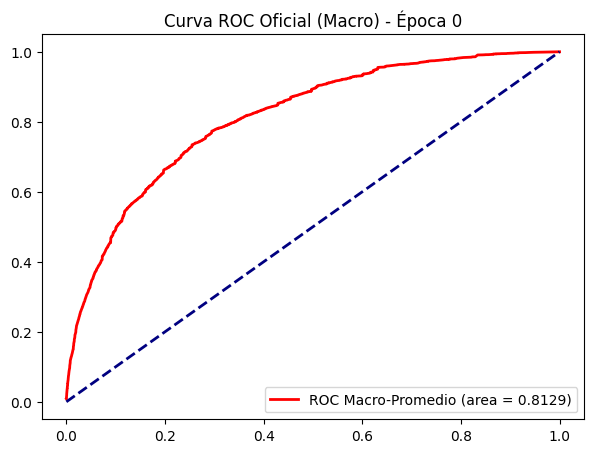

New best AUC: 0.8128 at epoch 1

Epoch 2/10


Training:   0%|          | 0/714 [00:00<?, ?it/s]

Validation:   0%|          | 0/179 [00:00<?, ?it/s]

Train Loss: 0.0239, Train AUC: 0.8097
Val Loss: 0.0211, Val AUC: 0.8874


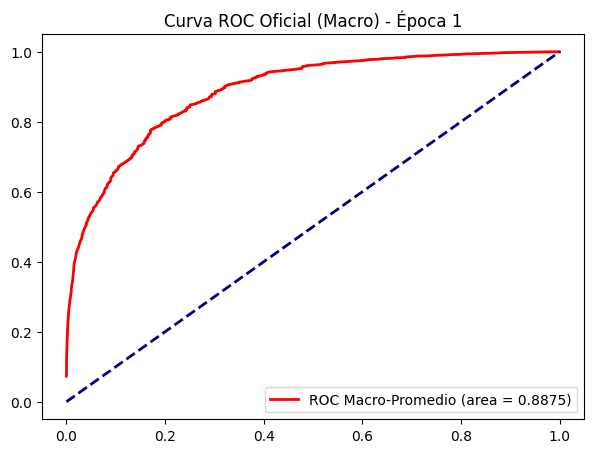

New best AUC: 0.8874 at epoch 2

Epoch 3/10


Training:   0%|          | 0/714 [00:00<?, ?it/s]

Validation:   0%|          | 0/179 [00:00<?, ?it/s]

Train Loss: 0.0196, Train AUC: 0.8932
Val Loss: 0.0182, Val AUC: 0.9198


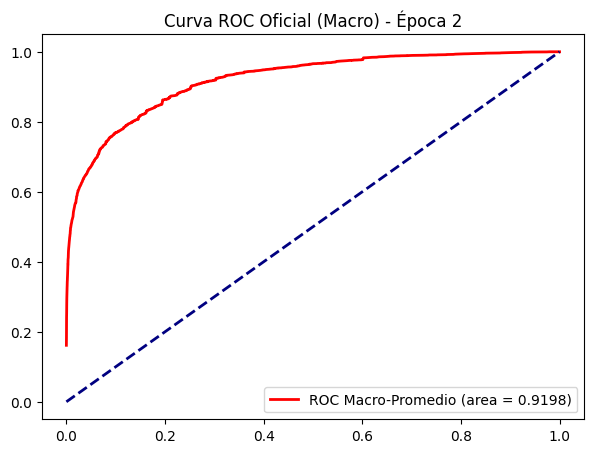

New best AUC: 0.9198 at epoch 3

Epoch 4/10


Training:   0%|          | 0/714 [00:00<?, ?it/s]

Validation:   0%|          | 0/179 [00:00<?, ?it/s]

Train Loss: 0.0170, Train AUC: 0.9310
Val Loss: 0.0168, Val AUC: 0.9343


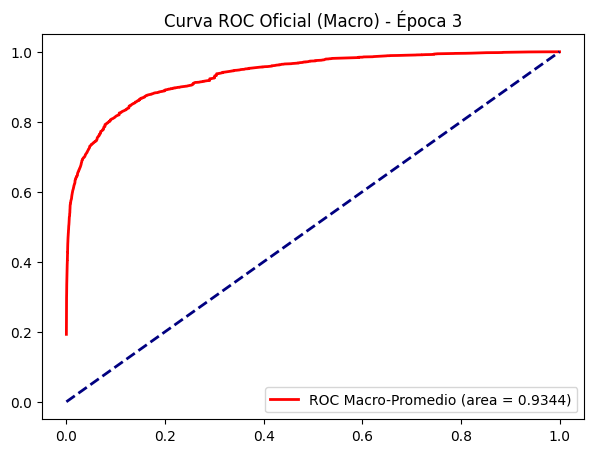

New best AUC: 0.9343 at epoch 4

Epoch 5/10


Training:   0%|          | 0/714 [00:00<?, ?it/s]

Validation:   0%|          | 0/179 [00:00<?, ?it/s]

Train Loss: 0.0151, Train AUC: 0.9515
Val Loss: 0.0159, Val AUC: 0.9400


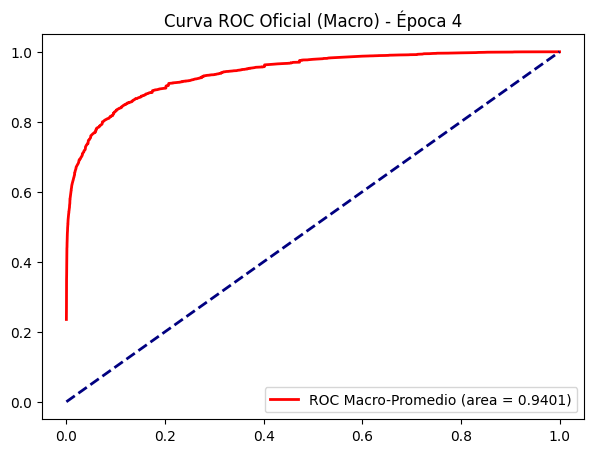

New best AUC: 0.9400 at epoch 5

Epoch 6/10


Training:   0%|          | 0/714 [00:00<?, ?it/s]

Validation:   0%|          | 0/179 [00:00<?, ?it/s]

Train Loss: 0.0134, Train AUC: 0.9675
Val Loss: 0.0159, Val AUC: 0.9417


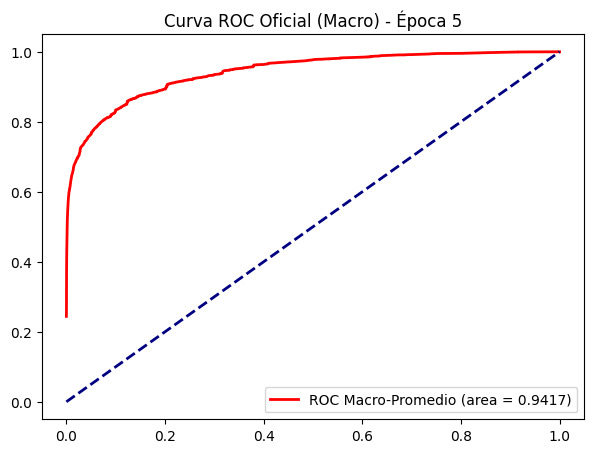

New best AUC: 0.9417 at epoch 6

Epoch 7/10


Training:   0%|          | 0/714 [00:00<?, ?it/s]

Validation:   0%|          | 0/179 [00:00<?, ?it/s]

Train Loss: 0.0120, Train AUC: 0.9763
Val Loss: 0.0160, Val AUC: 0.9425


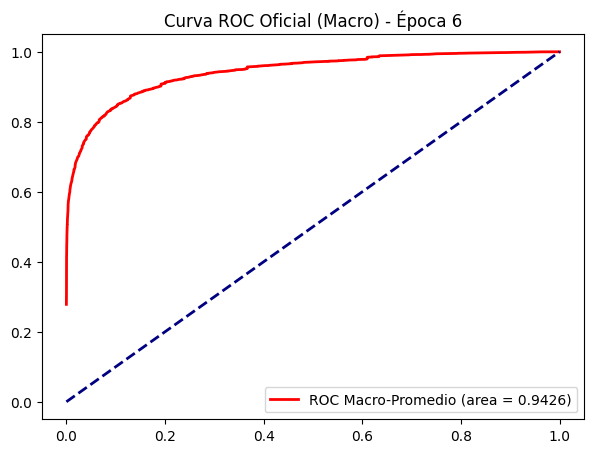

New best AUC: 0.9425 at epoch 7

Epoch 8/10


Training:   0%|          | 0/714 [00:00<?, ?it/s]

Validation:   0%|          | 0/179 [00:00<?, ?it/s]

Train Loss: 0.0107, Train AUC: 0.9833
Val Loss: 0.0165, Val AUC: 0.9425


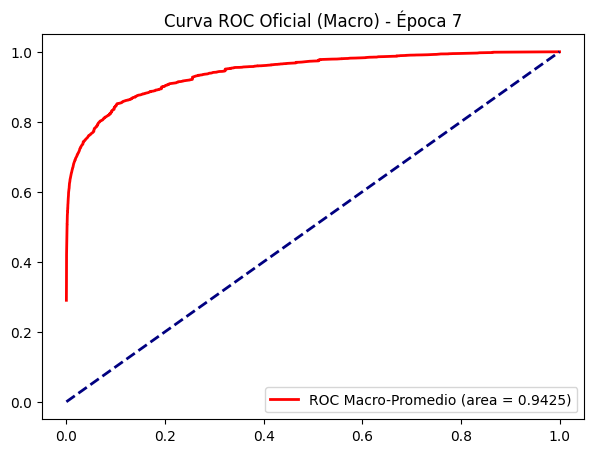


Epoch 9/10


Training:   0%|          | 0/714 [00:00<?, ?it/s]

Validation:   0%|          | 0/179 [00:00<?, ?it/s]

Train Loss: 0.0081, Train AUC: 0.9926
Val Loss: 0.0158, Val AUC: 0.9453


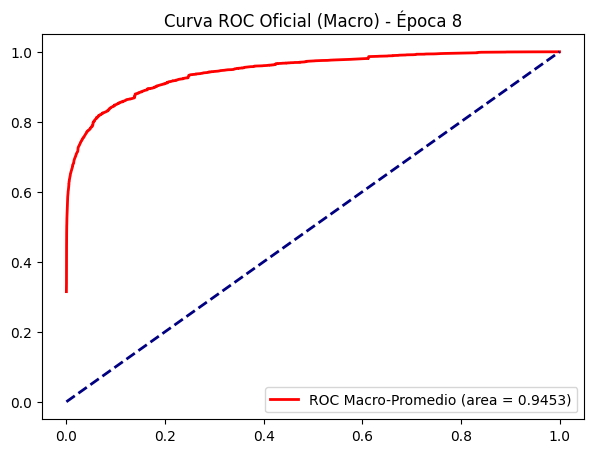

New best AUC: 0.9453 at epoch 9

Epoch 10/10


Training:   0%|          | 0/714 [00:00<?, ?it/s]

Validation:   0%|          | 0/179 [00:00<?, ?it/s]

Train Loss: 0.0068, Train AUC: 0.9953
Val Loss: 0.0164, Val AUC: 0.9429


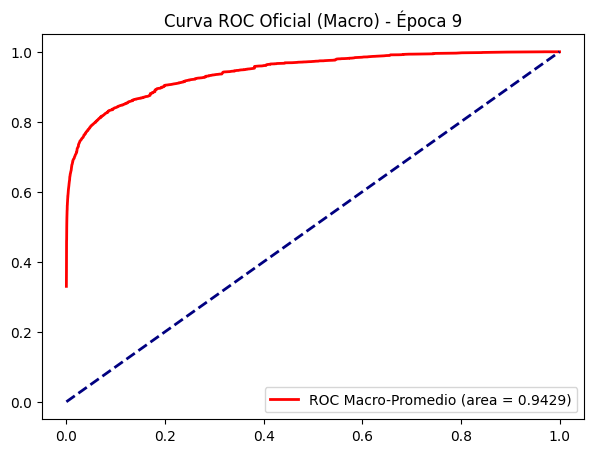


Best AUC for fold 0: 0.9453 at epoch 9

============================== Fold 1 ==============================
Training set: 22851 samples
Validation set: 5713 samples

Epoch 1/10


Training:   0%|          | 0/714 [00:00<?, ?it/s]

Validation:   0%|          | 0/179 [00:00<?, ?it/s]

In [ ]:
if __name__ == "__main__":
    import time

    print("\nLoading training data...")
    train_df = pd.read_csv(cfg.train_csv)
    taxonomy_df = pd.read_csv(cfg.taxonomy_csv)

    print("\nStarting training...")
    print(f"LOAD_DATA is set to {cfg.LOAD_DATA}")
    if cfg.LOAD_DATA:
        print("Using pre-computed mel spectrograms from NPY file")
    else:
        print("Will generate spectrograms on-the-fly during training")

    run_training(train_df, cfg)

    print("\nTraining complete!")

### **Resultados**
Se ejecutaron tres pruebas experimentales usando la GPU T4 de Google Colab, variando la combinación del optimizador y planificador sobre la primera partición \textit{Fold 0} durante un ciclo de diez épocas, esto debido a la limitación de los recursos computacionales. Para asegurar que los resultados no se afectaran por la partición de los datos se fijó una semilla para mantener siempre la misma separación en los conjuntos, obteniendo de este modo $22\ 851$ datos para entrenamiento y $5\ 713$ para validación, los resultados comparativos se sintetizan en la siguiente tabla:

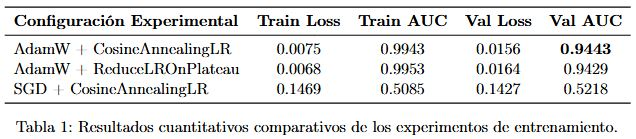

A continuación se presentan con mayor detalle los experimentos realizados.

**AdamW + CosineAnnelingLR**

Este experimento tuvo un tiempo de ejecución de 5 horas 23 minutos y 18 segundos

Época 1

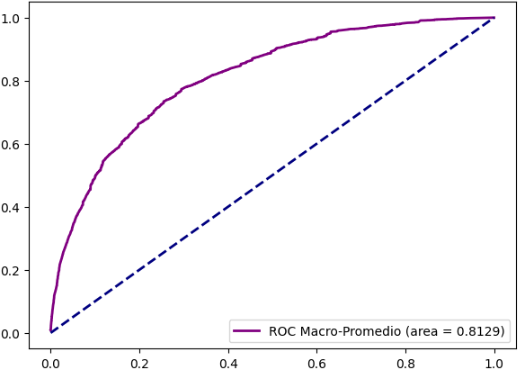

Época 5

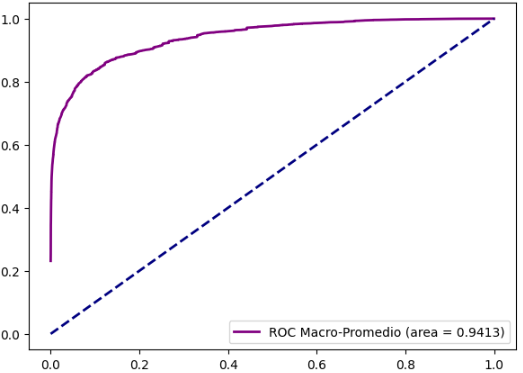

Época 10

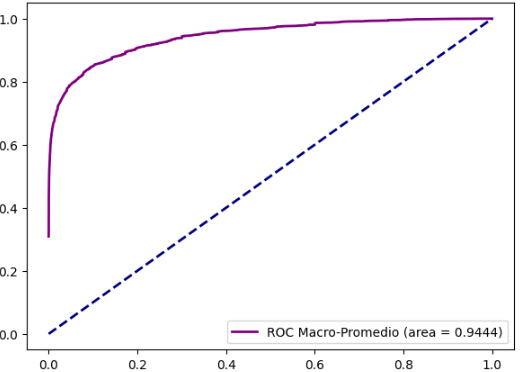

Macro ROC-AUC

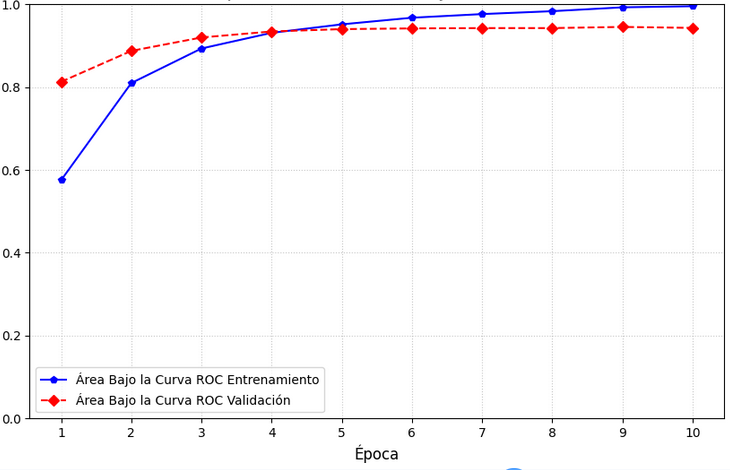

Función de pérdida

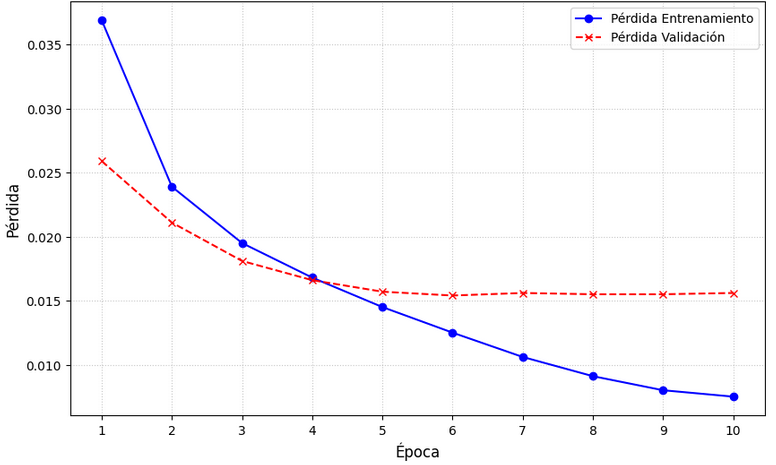

Evolución de la tasa de aprendizaje

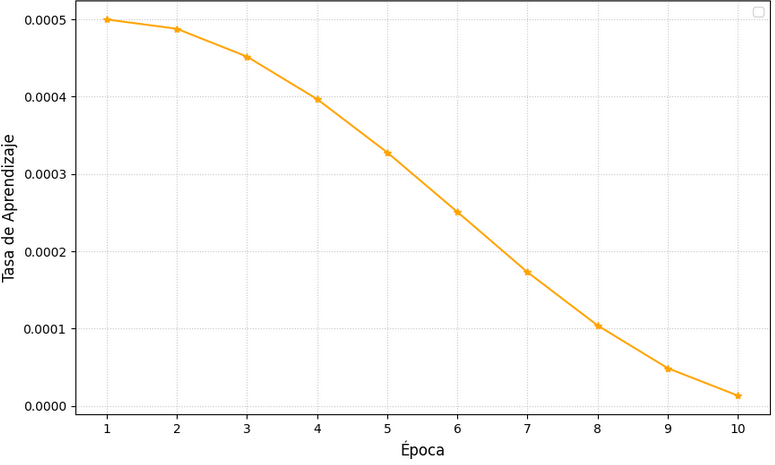

Como se observa en el comportamiento analizado, este modelo muestra una tasa de falsos positivos decreciente, empujando la curva macro de discriminación hacia el extremo superior izquierdo de forma constante con el paso de las épocas.

**AdamW + ReduceLROnPlateau**

Este experimento tuvo un tiempo de ejecución de 5 horas 7 minutos y 15 segundos

Época 1

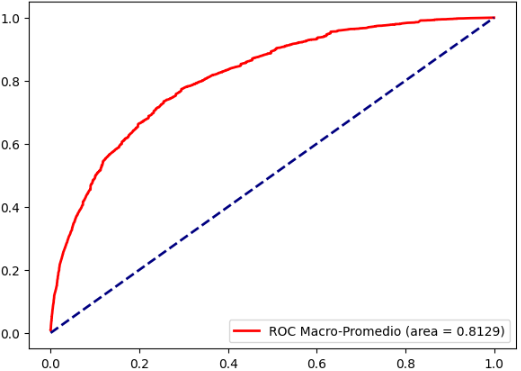

Época 5

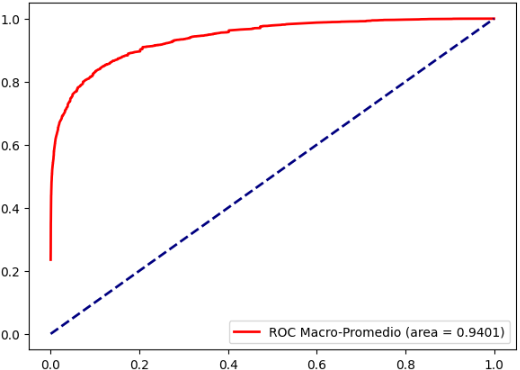

Época 10

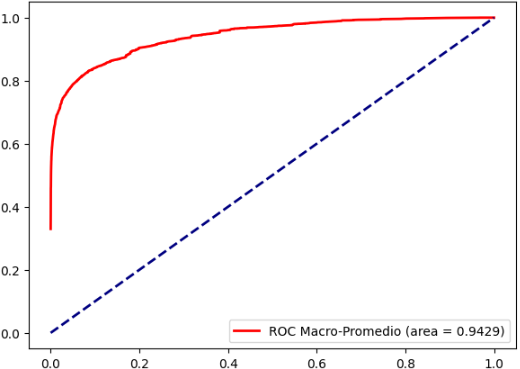

Macro ROC-AUC

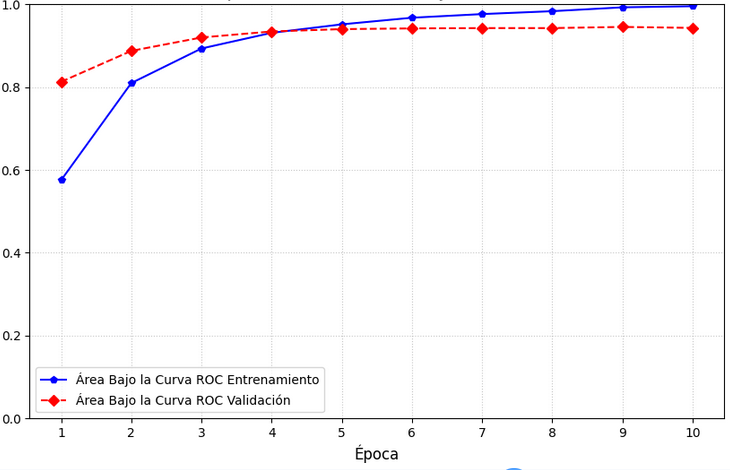

Función de pérdida

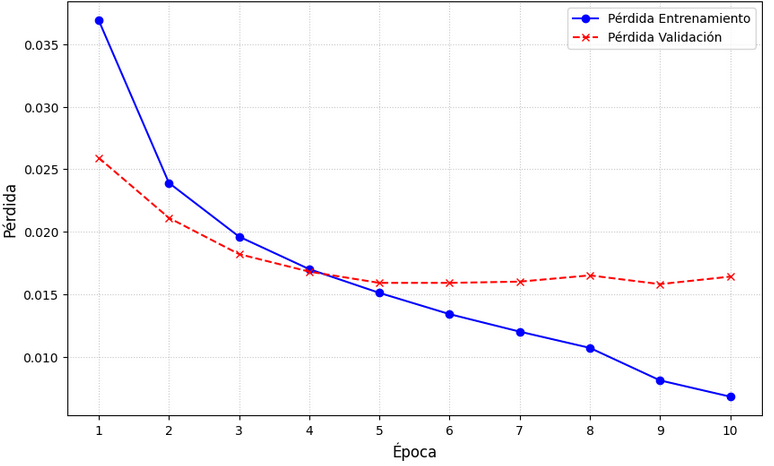

Evoluciòn de la tasa de aprendizaje

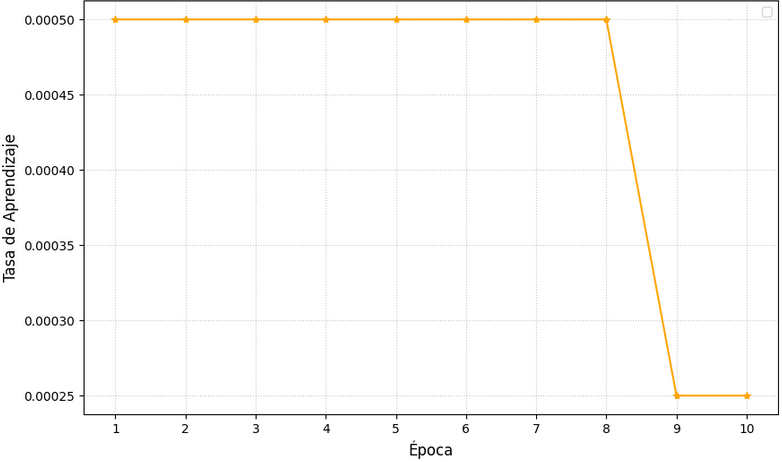

Este comportamiento demuestra que el extractor de características logra separar eficientemente los patrones visuales de los espectrogramas y además permite afirmar
que el optimizador hace el "trabajo pesado", dado que los dos experimentos mostrados dieron resultados casi idénticos, concluyendose así que en este ecosistema de datos, el optimizador adaptativo \textit{AdamW} es el responsable del éxito, sin importar tanto si el planificador bajaba el ritmo por tiempo o por estancamiento.

**SGD + CosineAnnelingLR**

Este experimento tuvo un tiempo de ejecución de 5 horas 10 minutos y 8 segundos

Época 1

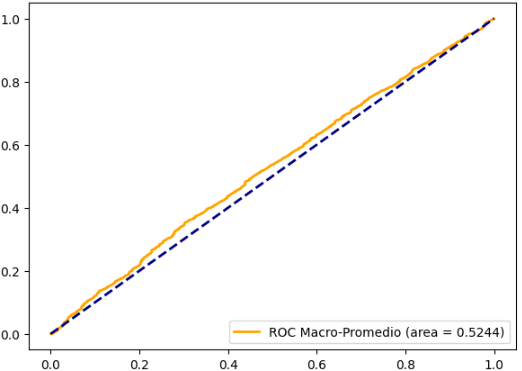

Época 5

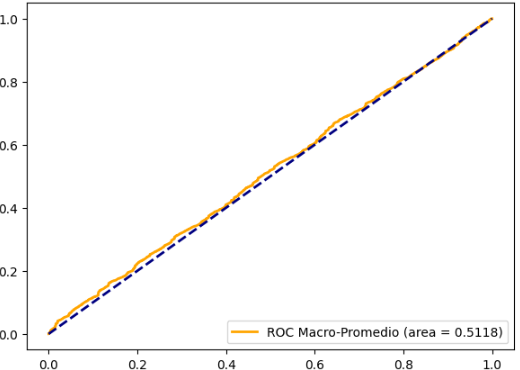

Época 10

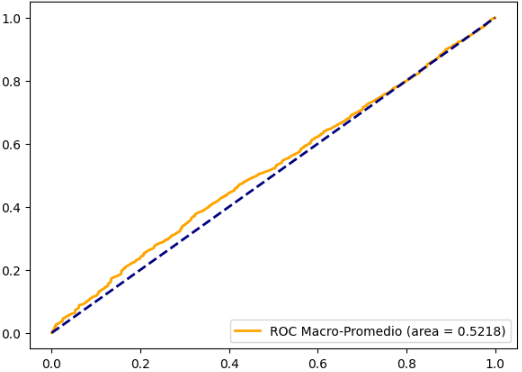

Macro ROC-AUC

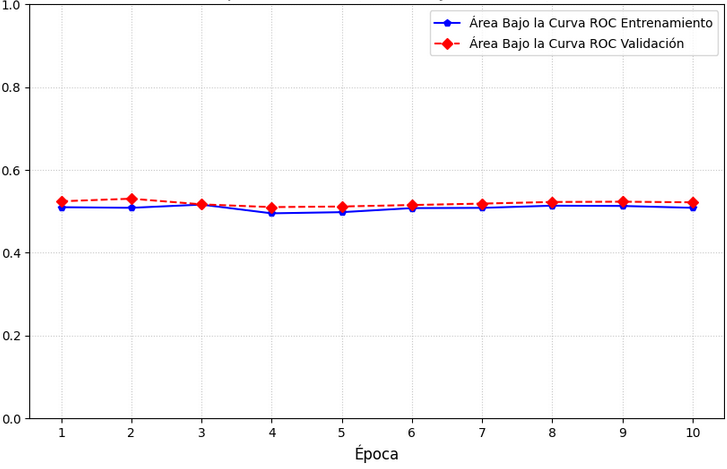

Función de pérdida

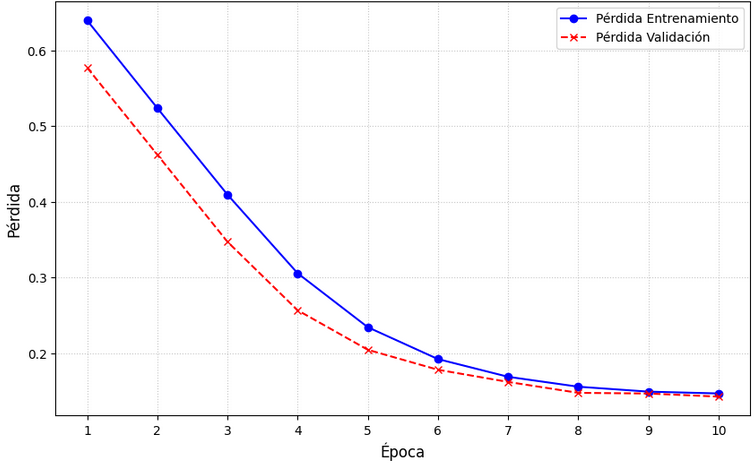

Evolución de la tasa de aprendizaje

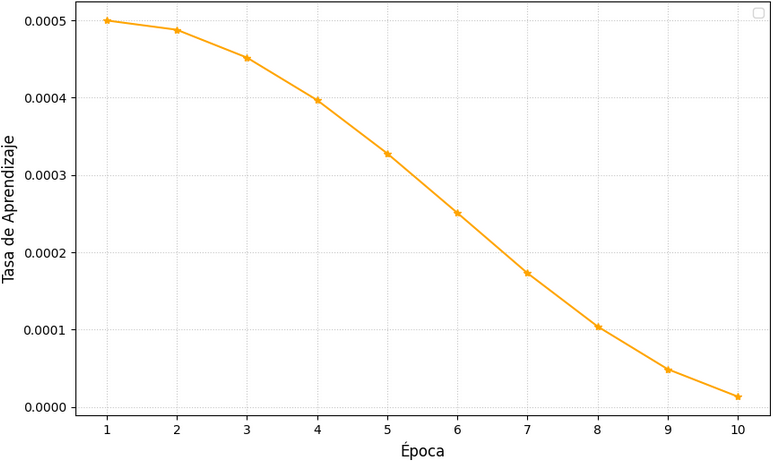

Como *SGD* no tiene tasas de aprendizaje adaptativas por cada parámetro, encontró dificultades, pues la naturaleza multietiqueta de los datos donde la inmensa mayoría de las clases en un audio dado son negativas (es decir, se escucha $1$ especie, y las otras especies son $0$), hacen que para reducir la pérdida matemática lo más rápido posible, el modelo pudo predecir que no hay ningún pájaro en absoluto, así como el $99\%$ de las etiquetas reales en la matriz son ceros, predecir "solo ceros" hace que la pérdida matemática baje drásticamente (porque acierta casi todo). Sin embargo, la métrica Macro AUC castiga severamente esto, porque evalúa la capacidad de detectar los Verdaderos Positivos.

### **Conclusiones**
La investigación determinó el impacto directo que poseen los hiperparámetros de optimización sobre datos bioacústicos, mostrando la superioridad del optimizador adaptativo *AdamW*, el cual alcanzó un rendimiento sobresaliente con un Macro ROC-AUC de más de $0.94$ en ambos escenarios de planificación (*CosineAnnealing* y *ReduceLROnPlateau*) tras solo $10$ épocas.

La similitud en los resultados de los experimentos $1$ y $2$ sugieren que, dada la capacidad de *AdamW* para calcular tasas de aprendizaje individuales por parámetro, la red logra una convergencia rápida y estable hacia mínimos globales, haciendo que la elección del planificador sea un factor secundario para este número de épocas. La pérdida de validación decreciente hacia niveles cercanos a cero confirma una alta capacidad de discriminación sin evidencia de sobreajuste temprano.

Por otro lado, el experimento $3$ evidenció una limitación crítica del optimizador *SGD* en este dominio. A pesar de registrar un descenso consistente en la función de pérdida, el modelo fue incapaz de superar un Macro ROC-AUC de $0.53$. Este fenómeno puede atribuirse a la naturaleza multietiqueta y a la alta escasez (*sparsity*) de positivos en la matriz de etiquetas, el optimizador *SGD* tendió a colapsar sus predicciones hacia la clase mayoritaria. Esto minimiza artificialmente el error global de entropía cruzada, pero destruye la capacidad del modelo para distinguir *Verdaderos Positivos*, lo cual es penalizado por la métrica Macro ROC-AUC que pondera a todas las especies por igual.

Se concluye que, para la clasificación masiva de espectrogramas con arquitecturas convolucionales, el uso de optimizadores con tasas adaptativas y decaimiento de pesos desacoplado como *AdamW* mejoran la velocidad de convergencia y evitan el colapso del modelo frente al desbalance de clases intrínseco de la ecología acústica.

### **Bibliografía**
1. Facultad de Estudios Ambientales y Rurales. Restauración ecológica: ¿cómo se recuperan los ecosistemas dañados? [Internet]. Bogotá: Bitácora EAR, Pontificia Universidad Javeriana; 2026 [citado 10 de jun. de 2026]. Disponible en: https://fear.javeriana.edu.co/w/blog/que-es-restauracion-ecologica

2. Fundación Natura Colombia. Reserva Biológica El Silencio [Internet]. Bogotá: Fundación Natura; 2024 [citado 10 de jun. de 2026]. Disponible en: https://natura.org.co/reservas/reserva-biologica-silencio/

3. İdrisoğlu, K. (s.f.). Perfil de LinkedIn. LinkedIn. Disponible en: https://www.linkedin.com/in/kadircan-idrisoglu-569467231/

4. Dias, F. F., Ponti, M. A., \& Minghim, R. (2025). Enhancing sound-based classification of birds and anurans with spectrogram representations and acoustic indices in neural network architectures. Ecological Informatics, 90, 103232. https://sciencedirect.unalproxy.elogim.com/science/article/pii/S1574954125002419

5. Kaggle. BirdCLEF+ 2025 [Internet]. San Francisco: Kaggle; 2025 [citado 10 de jun. de 2026]. Disponible en: https://www.kaggle.com/competitions/birdclef-2025/overview

6. Pykes, K. (2024, 22 de octubre). Tutorial del Optimizador AdamW en PyTorch. DataCamp. https://www.datacamp.com/es/tutorial/adamw-optimizer-in-pytorch